# Replication: Global Sustainability Performance and Regional Disparities
**Paper:** Çelik et al. (2025), *MDPI Sustainability 17, 7411*  
**DOI:** https://doi.org/10.3390/su17167411  
**Figures reproduced in paper order:** Fig 1 → Fig 2 → Fig 3 → Fig 4 → Table 2 → Fig 5 → Fig 6 → Fig 7 → Tables 3–4 → Fig 8 → Table 5 → Fig 9 → Fig 10

In [ ]:
import os
os.makedirs('replication_results', exist_ok=True)
print('replication_results/ folder ready')

## 0. Setup — load data, rename columns, scale, PCA, cluster
*Run this cell first. All subsequent cells depend on the variables defined here.*

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as path_effects
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve,
                              accuracy_score)
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# ── Load & rename ──────────────────────────────────────────────────────────
df = pd.read_csv("SDG2025.csv", sep=';', encoding='ISO-8859-1', engine='python')
df = df.rename(columns={
    'Country': 'country',
    '2025 SDG Index Score': 'sdg_score',
    'International Spillovers Score (0-100)': 'spillover_score',
    'Regional Score (0-100)': 'regional_score',
    'Population in 2024': 'population',
    'Progress on Headline SDGi (p.p.)': 'progress',
    'Regions used for the SDR': 'region'
})

# ── Feature matrix ─────────────────────────────────────────────────────────
features = ['sdg_score', 'spillover_score', 'regional_score', 'population', 'progress']
X = df[features].dropna()
df_clean = df.loc[X.index].copy()

# ── Standardise ───────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── PCA (3 components) ────────────────────────────────────────────────────
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.4f}, "
      f"PC2={pca.explained_variance_ratio_[1]:.4f}, "
      f"PC3={pca.explained_variance_ratio_[2]:.4f}")
print(f"Total: {pca.explained_variance_ratio_.sum():.4f}")

# ── K-Means k=5 ──────────────────────────────────────────────────────────
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)
df_clean['cluster'] = labels
df_clean['PCA1'] = X_pca[:, 0]
df_clean['PCA2'] = X_pca[:, 1]
df_clean['PCA3'] = X_pca[:, 2]

sil = silhouette_score(X_scaled, labels)
print(f"\nK-Means k=5 silhouette score: {sil:.4f}")
print("Cluster sizes:", df_clean['cluster'].value_counts().sort_index().to_dict())

PCA explained variance: PC1=0.5084, PC2=0.2049, PC3=0.1771
Total: 0.8904

K-Means k=5 silhouette score: 0.3971
Cluster sizes: {0: 55, 1: 37, 2: 23, 3: 2, 4: 26}


## Figure 1 — Circular Methodological Flow

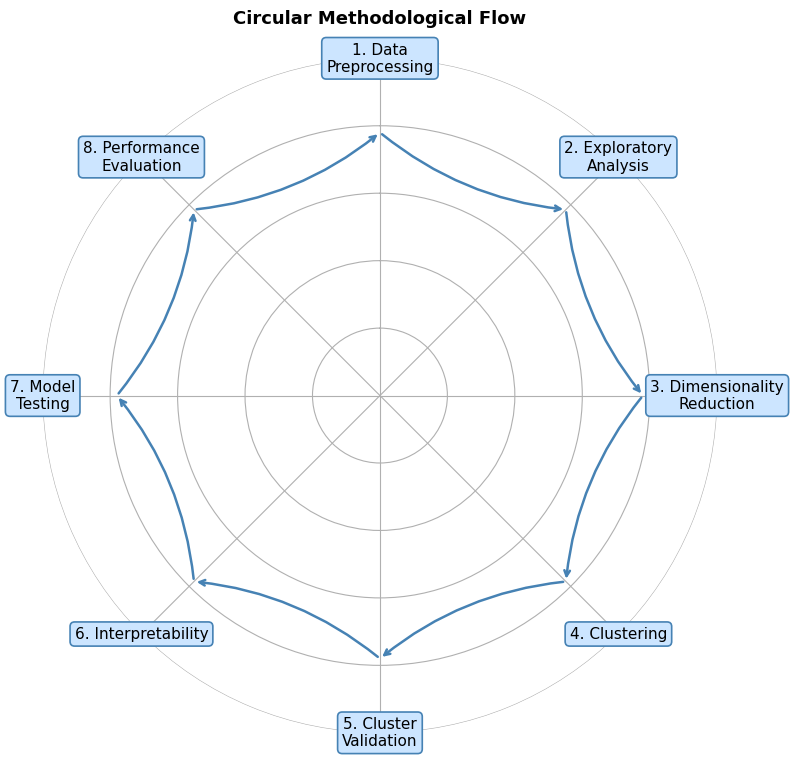

In [2]:
import numpy as np
import matplotlib.pyplot as plt

steps = [
    "1. Data\nPreprocessing",
    "2. Exploratory\nAnalysis",
    "3. Dimensionality\nReduction",
    "4. Clustering",
    "5. Cluster\nValidation",
    "6. Interpretability",
    "7. Model\nTesting",
    "8. Performance\nEvaluation"
]

angles = np.linspace(0, 2 * np.pi, len(steps), endpoint=False)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True})
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_yticklabels([])
ax.set_xticklabels([])
ax.spines['polar'].set_visible(False)
ax.set_facecolor('white')

for angle, step in zip(angles, steps):
    ax.text(angle, 1.0, step, ha='center', va='center', fontsize=11,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#cce5ff", edgecolor='steelblue', linewidth=1.2))

for i in range(len(steps)):
    a1, a2 = angles[i], angles[(i + 1) % len(steps)]
    ax.annotate("",
                xy=(a2, 0.78), xytext=(a1, 0.78),
                arrowprops=dict(arrowstyle="->", color='steelblue', lw=1.8,
                                connectionstyle="arc3,rad=0.15"))

plt.title("Circular Methodological Flow", fontsize=13, weight='bold', pad=25)
plt.tight_layout()
plt.savefig("replication_results/fig1_circular_flow.png", dpi=150, bbox_inches='tight')
plt.show()

## Figure 2 — Top 20 & Bottom 20 Countries by 2025 SDG Score

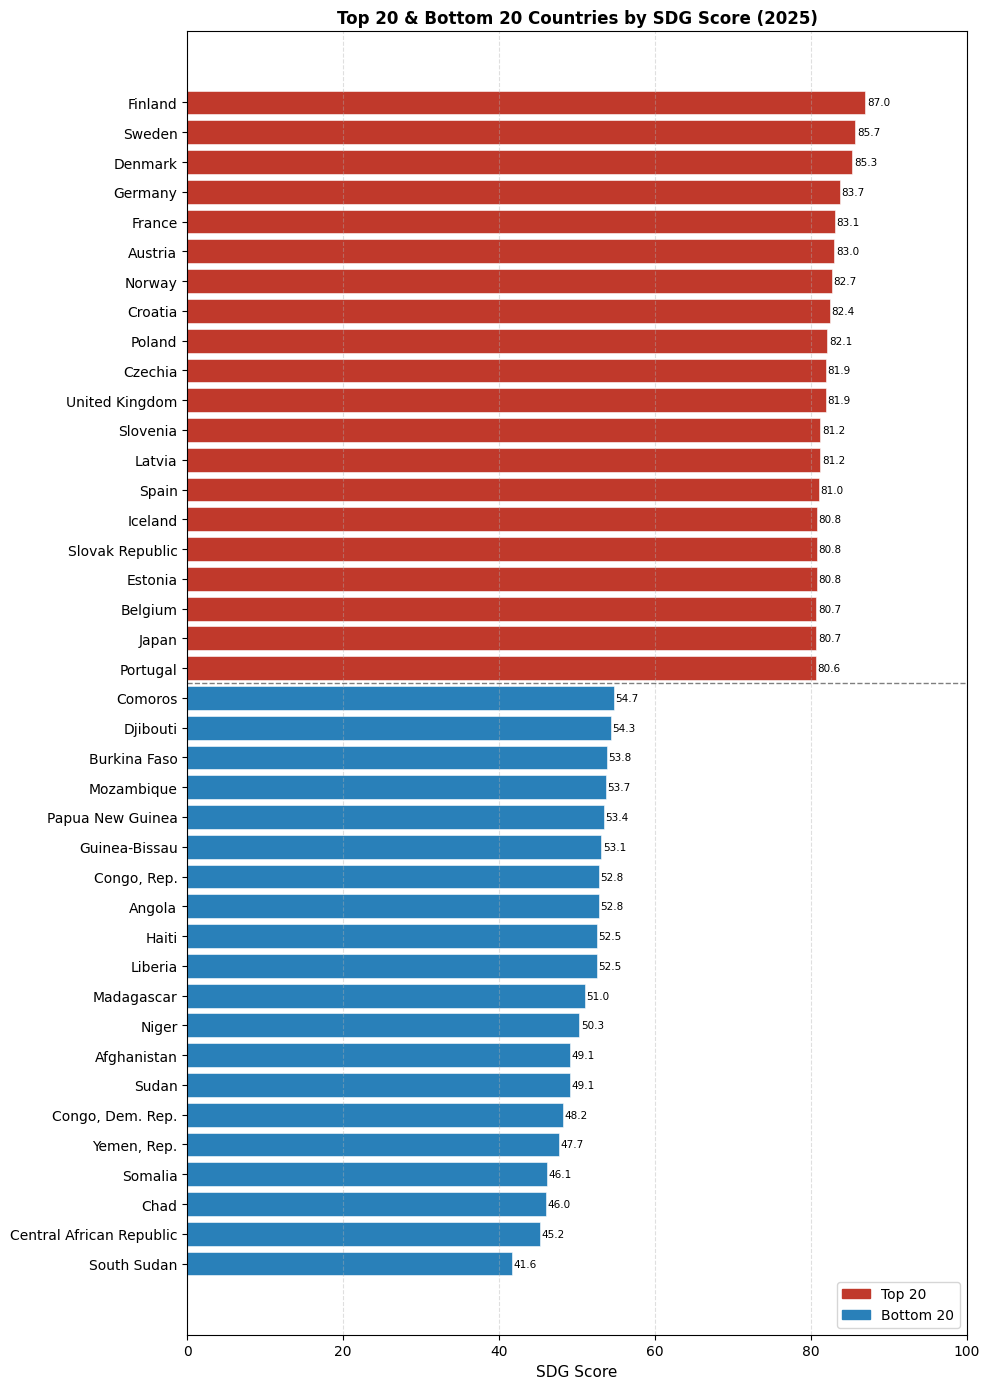

In [3]:
fig_df = df[['country', 'sdg_score']].dropna().sort_values('sdg_score', ascending=False)
top20    = fig_df.head(20)
bottom20 = fig_df.tail(20).sort_values('sdg_score', ascending=False)
combined = pd.concat([top20, bottom20])

colors = ['#c0392b'] * 20 + ['#2980b9'] * 20  # red = top, blue = bottom

fig, ax = plt.subplots(figsize=(10, 14))
bars = ax.barh(combined['country'][::-1], combined['sdg_score'][::-1],
               color=colors[::-1], edgecolor='white', linewidth=0.4)

for bar, val in zip(bars, combined['sdg_score'][::-1]):
    ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}', va='center', ha='left', fontsize=7.5, color='black')

ax.axhline(y=19.5, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax.set_xlabel('SDG Score', fontsize=11)
ax.set_title('Top 20 & Bottom 20 Countries by SDG Score (2025)', fontsize=12, weight='bold')
ax.set_xlim(0, 100)
ax.grid(axis='x', linestyle='--', alpha=0.4)

top_patch    = mpatches.Patch(color='#c0392b', label='Top 20')
bottom_patch = mpatches.Patch(color='#2980b9', label='Bottom 20')
ax.legend(handles=[top_patch, bottom_patch], fontsize=10, loc='lower right')

plt.tight_layout()
plt.savefig("replication_results/fig2_top_bottom20_sdg.png", dpi=150, bbox_inches='tight')
plt.show()

## Figure 3 — Top 20 Countries by 4 Key SDG Indicators (2×2 grid)

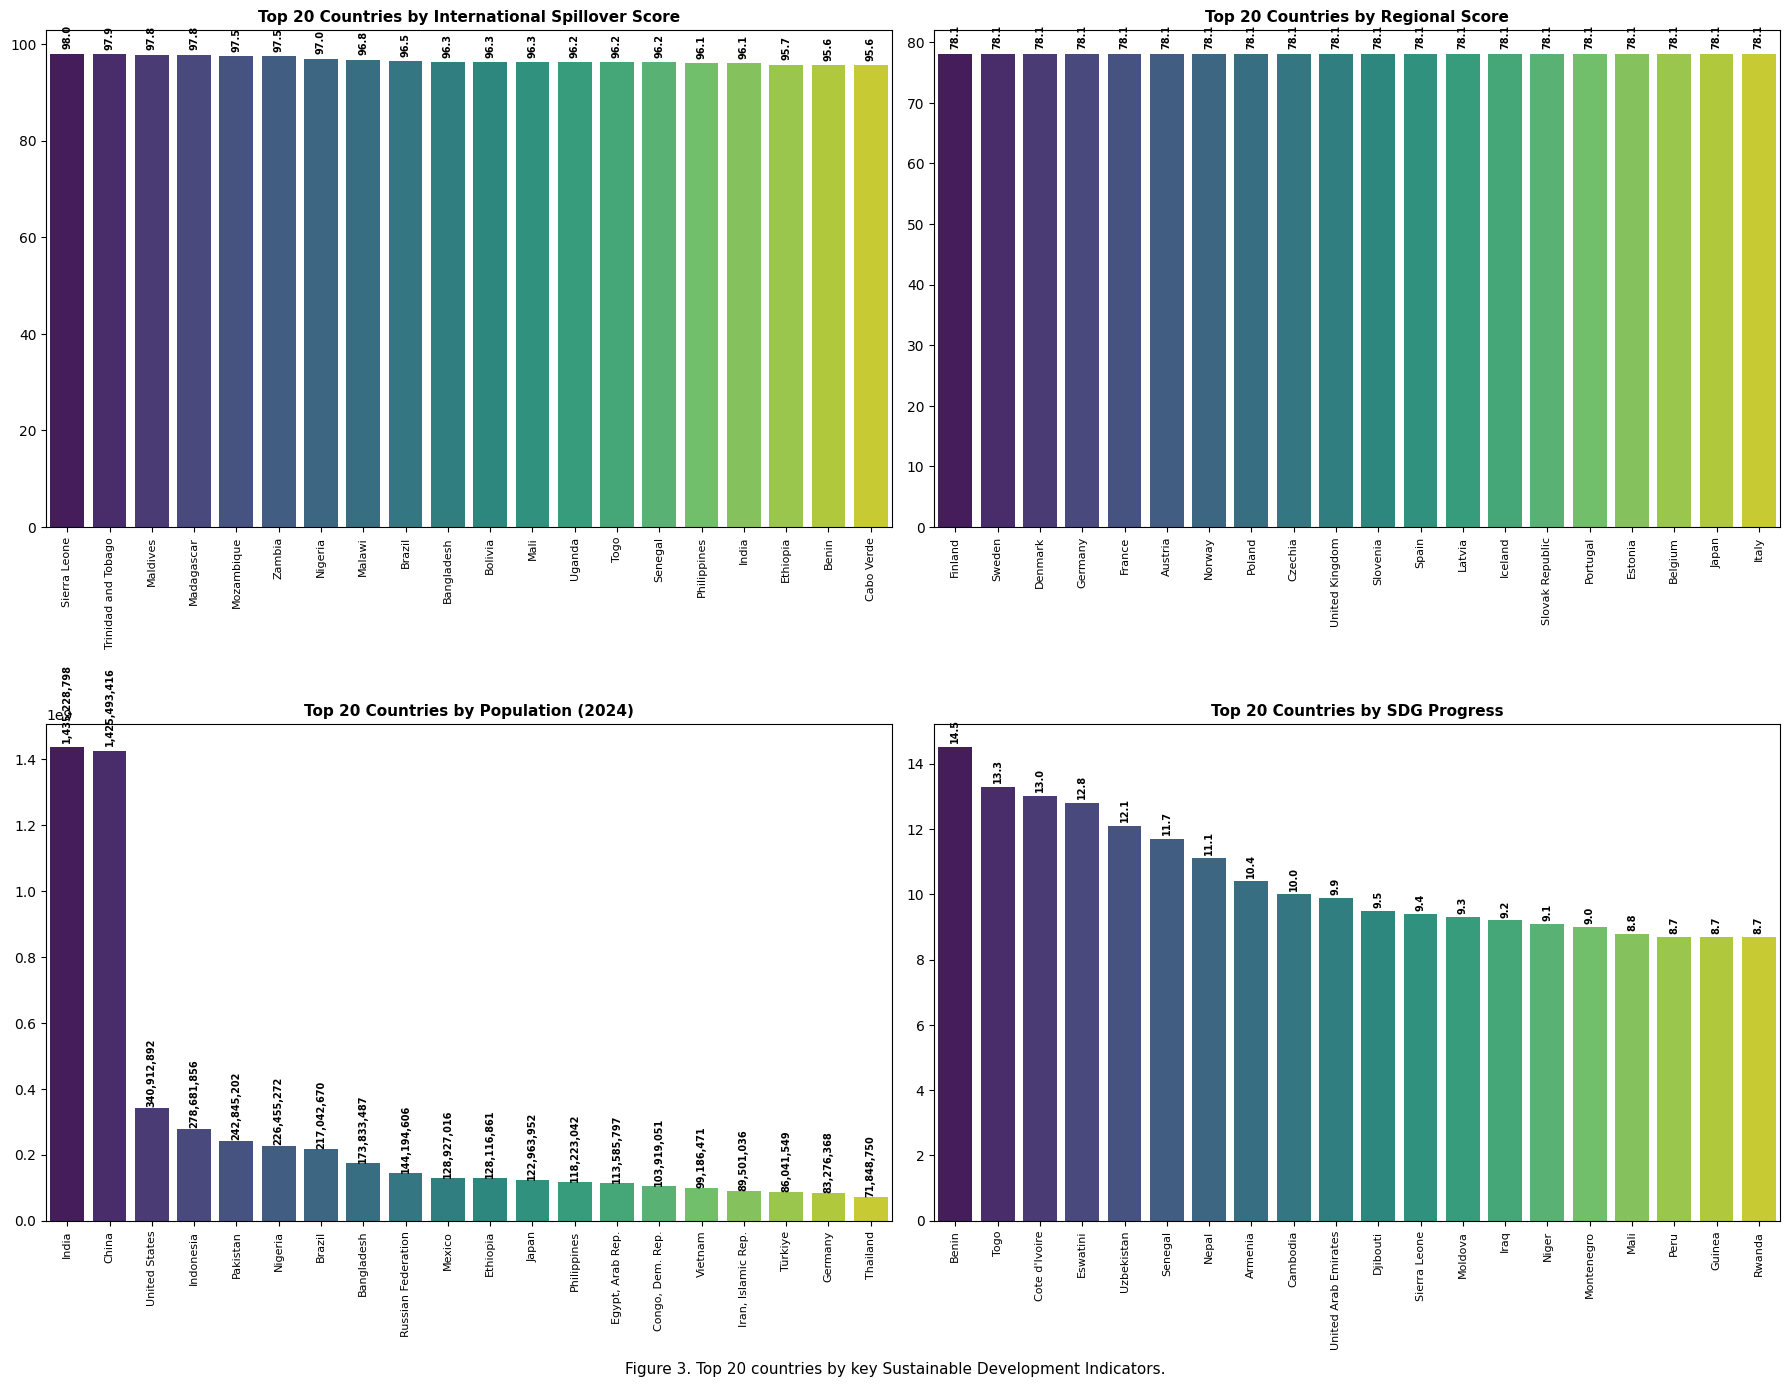

In [4]:
variables = ['spillover_score', 'regional_score', 'population', 'progress']
titles = [
    'Top 20 Countries by International Spillover Score',
    'Top 20 Countries by Regional Score',
    'Top 20 Countries by Population (2024)',
    'Top 20 Countries by SDG Progress'
]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 14))
axes = axes.flatten()

for ax, var, title in zip(axes, variables, titles):
    top20 = df.sort_values(by=var, ascending=False).head(20)
    palette = sns.color_palette("viridis", 20)
    sns.barplot(x='country', y=var, data=top20, palette='viridis',
                ax=ax, hue='country', legend=False)

    for p in ax.patches:
        h = p.get_height()
        if h > 0.1:
            label = f'{int(h):,}' if var == 'population' else f'{h:.1f}'
            ax.text(p.get_x() + p.get_width() / 2, h + (h * 0.01),
                    label, ha='center', va='bottom', fontsize=7, rotation=90, fontweight='bold')

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelrotation=90, labelsize=8)

plt.suptitle('Figure 3. Top 20 countries by key Sustainable Development Indicators.',
             fontsize=11, y=0.002)
plt.tight_layout()
plt.savefig("replication_results/fig3_top20_indicators.png", dpi=150, bbox_inches='tight')
plt.show()

## Figure 4 — Correlation Matrix

Correlation Matrix:
                 sdg_score  spillover_score  regional_score  population  \
sdg_score             1.00            -0.65            0.82        0.01   
spillover_score      -0.65             1.00           -0.62        0.12   
regional_score        0.82            -0.62            1.00        0.04   
population            0.01             0.12            0.04        1.00   
progress             -0.16             0.32           -0.34        0.02   

                 progress  
sdg_score           -0.16  
spillover_score      0.32  
regional_score      -0.34  
population           0.02  
progress             1.00  


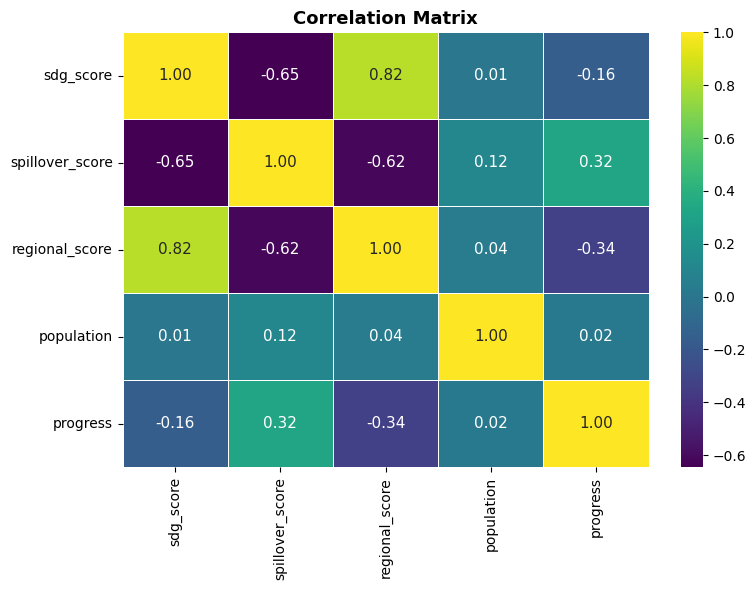

In [5]:
corr = df_clean[features].corr()

print("Correlation Matrix:")
print(corr.round(2))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='viridis', fmt=".2f",
            linewidths=0.5, ax=ax, annot_kws={"size": 11})
ax.set_title("Correlation Matrix", fontsize=13, weight='bold')
plt.tight_layout()
plt.savefig("replication_results/fig4_correlation.png", dpi=150, bbox_inches='tight')
plt.show()

## Table 2 & Figure 5 — Elbow Method and Silhouette Score

  k    WCSS (Inertia)   Silhouette Score
------------------------------------------
  2            461.12             0.3546
  3            331.77             0.3885
  4            219.37             0.4060
  5            169.03             0.3971
  6            147.63             0.3743
  7            128.90             0.3322
  8            116.06             0.3444
  9            104.60             0.3603
 10             92.85             0.3189


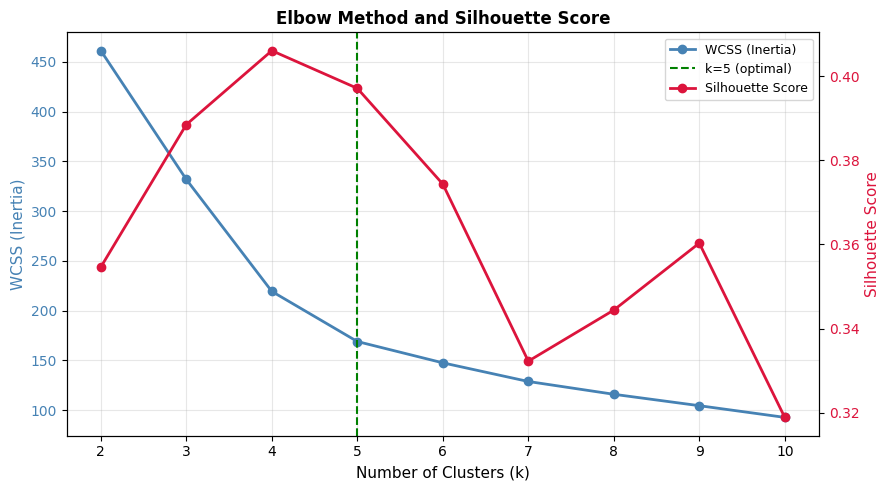

In [6]:
wcss, sil_scores = [], []
K = range(2, 11)

print(f"{'k':>3}  {'WCSS (Inertia)':>16}  {'Silhouette Score':>17}")
print("-" * 42)
for k_val in K:
    km = KMeans(n_clusters=k_val, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    s = silhouette_score(X_scaled, lbl)
    sil_scores.append(s)
    print(f"{k_val:>3}  {km.inertia_:>16.2f}  {s:>17.4f}")

# Figure 5
fig, ax1 = plt.subplots(figsize=(9, 5))

color_blue = 'steelblue'
color_red  = 'crimson'

ax1.plot(K, wcss, 'o-', color=color_blue, label='WCSS (Inertia)', linewidth=2)
ax1.set_xlabel('Number of Clusters (k)', fontsize=11)
ax1.set_ylabel('WCSS (Inertia)', color=color_blue, fontsize=11)
ax1.tick_params(axis='y', labelcolor=color_blue)

ax2 = ax1.twinx()
ax2.plot(K, sil_scores, 'o-', color=color_red, label='Silhouette Score', linewidth=2)
ax2.set_ylabel('Silhouette Score', color=color_red, fontsize=11)
ax2.tick_params(axis='y', labelcolor=color_red)

ax1.axvline(x=5, color='green', linestyle='--', linewidth=1.5, label='k=5 (optimal)')
ax1.set_title('Elbow Method and Silhouette Score', fontsize=12, weight='bold')
ax1.grid(True, alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig("replication_results/fig5_elbow_silhouette.png", dpi=150, bbox_inches='tight')
plt.show()

## Figure 6 — 3D PCA Cluster Visualisation with Country Labels

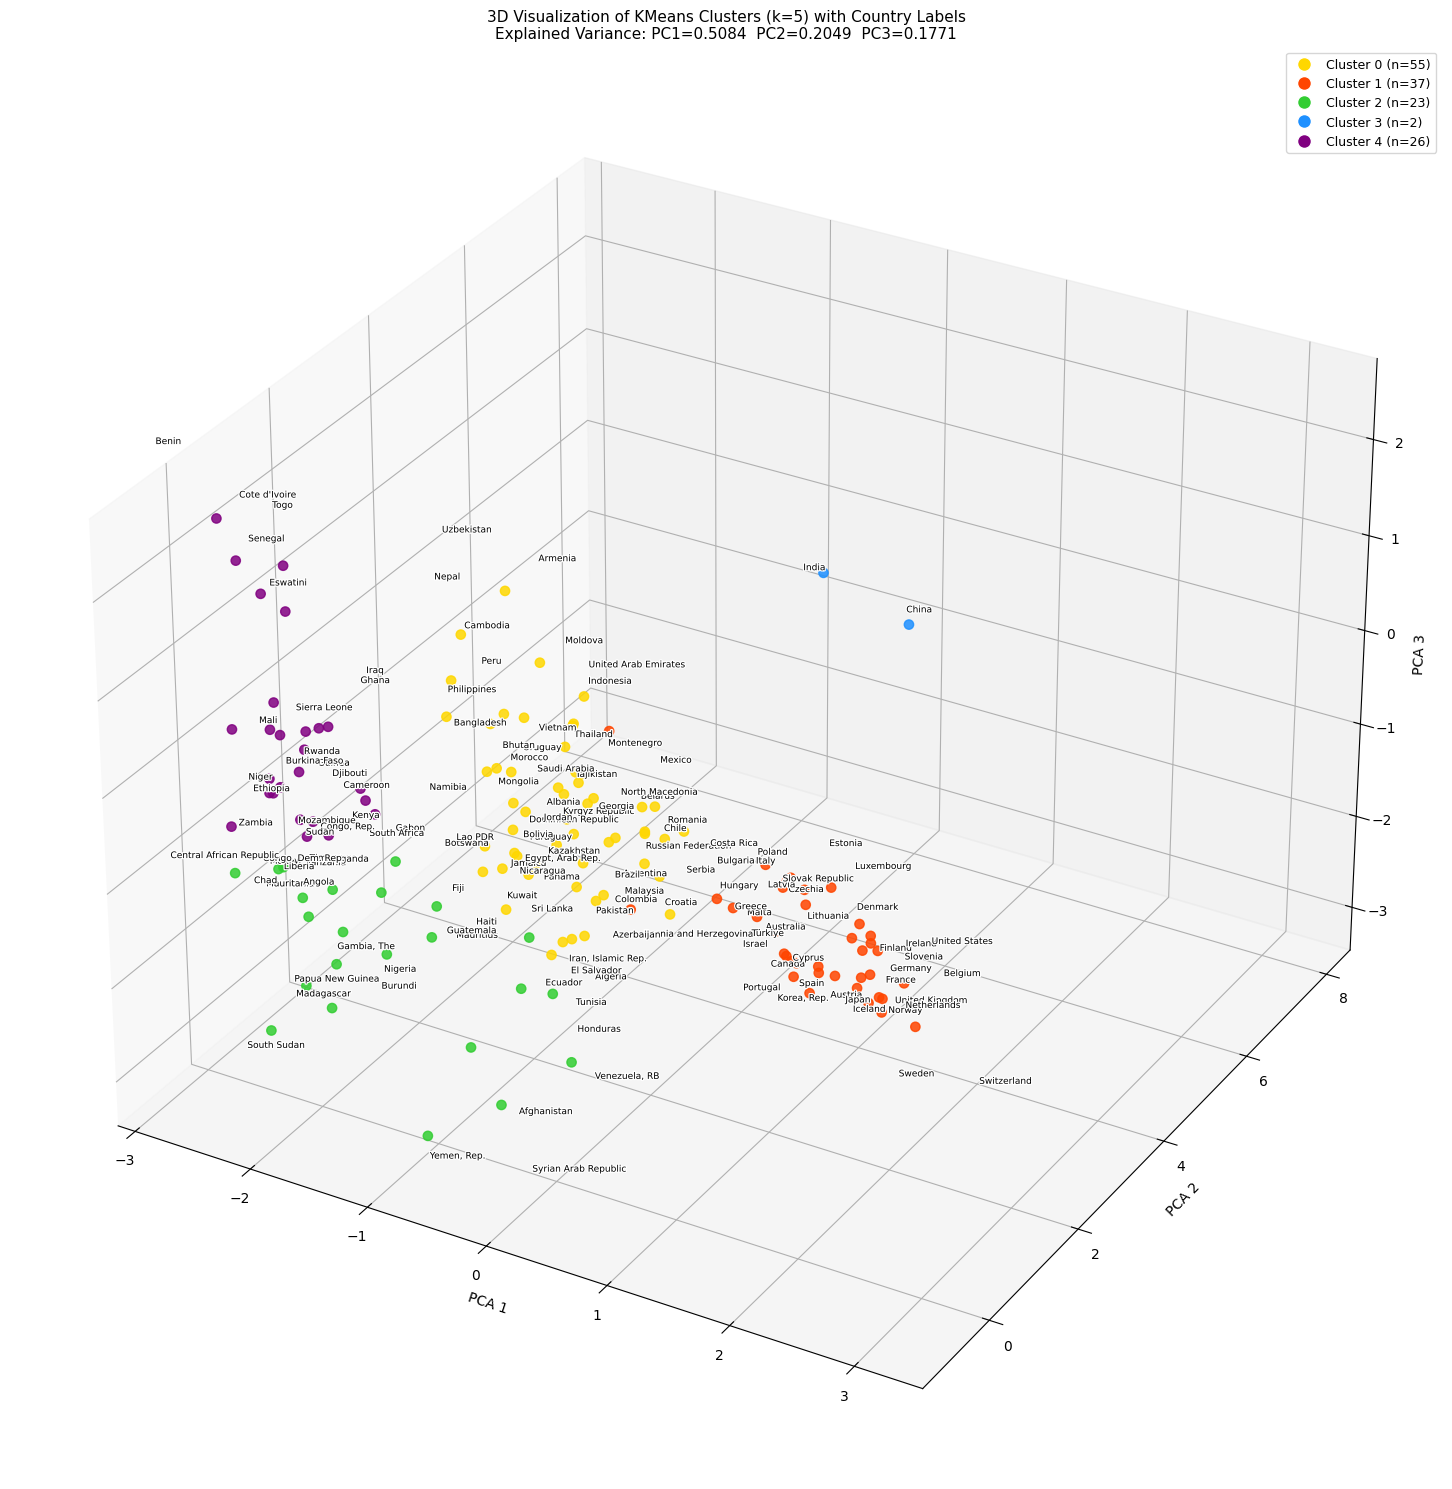


Cluster sizes:
cluster
0    55
1    37
2    23
3     2
4    26
Name: count, dtype: int64

Silhouette score (k=5): 0.3971


In [7]:
from mpl_toolkits.mplot3d import Axes3D

cluster_colors = ['#FFD700', '#FF4500', '#32CD32', '#1E90FF', '#800080']
cluster_counts = df_clean['cluster'].value_counts().sort_index()

# Refit with k=5 (uses variables from setup cell)
k = 5
kmeans5 = KMeans(n_clusters=k, random_state=42, n_init=10)
labels5 = kmeans5.fit_predict(X_scaled)
df_clean['cluster'] = labels5
centers_pca = pca.transform(kmeans5.cluster_centers_)

np.random.seed(42)
offsets = np.random.uniform(-0.4, 0.4, size=(len(df_clean), 3))

fig = plt.figure(figsize=(20, 15))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
    c=[cluster_colors[l] for l in labels5], s=45, alpha=0.85
)

for i, row in df_clean.reset_index(drop=True).iterrows():
    cid = int(row['cluster'])
    cx, cy, cz = centers_pca[cid]
    nx = X_pca[i, 0] + offsets[i, 0] + (X_pca[i, 0] - cx) * 0.3
    ny = X_pca[i, 1] + offsets[i, 1] + (X_pca[i, 1] - cy) * 0.3
    nz = X_pca[i, 2] + offsets[i, 2] + (X_pca[i, 2] - cz) * 0.3
    txt = ax.text(nx, ny, nz, row['country'], size=6.5, color='black')
    txt.set_path_effects([
        path_effects.Stroke(linewidth=1.8, foreground='white'),
        path_effects.Normal()
    ])

ev = pca.explained_variance_ratio_
ax.set_xlabel(f'PCA 1')
ax.set_ylabel(f'PCA 2')
ax.set_zlabel(f'PCA 3')
ax.set_title(f'3D Visualization of KMeans Clusters (k=5) with Country Labels\n'
             f'Explained Variance: PC1={ev[0]:.4f}  PC2={ev[1]:.4f}  PC3={ev[2]:.4f}',
             fontsize=11)

cluster_counts2 = df_clean['cluster'].value_counts().sort_index()
handles = [plt.Line2D([], [], marker='o', color='w', markerfacecolor=cluster_colors[i],
                      markersize=10, label=f'Cluster {i} (n={cluster_counts2[i]})')
           for i in range(k)]
ax.legend(handles=handles, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig("replication_results/fig6_3d_pca_clusters.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nCluster sizes:")
print(cluster_counts2)
print(f"\nSilhouette score (k=5): {silhouette_score(X_scaled, labels5):.4f}")

## Figure 7 — Normalised Average Feature Scores per Cluster

Normalized Average Feature Scores per Cluster (Min-Max scaled):
         sdg_score  spillover_score  regional_score  population  progress
cluster                                                                  
0            0.639            0.858           0.712       0.012     0.629
1            1.000            0.000           1.000       0.005     0.185
2            0.000            1.000           0.220       0.017     0.000
3            0.622            0.973           0.674       1.000     0.696
4            0.090            1.000           0.000       0.000     1.000


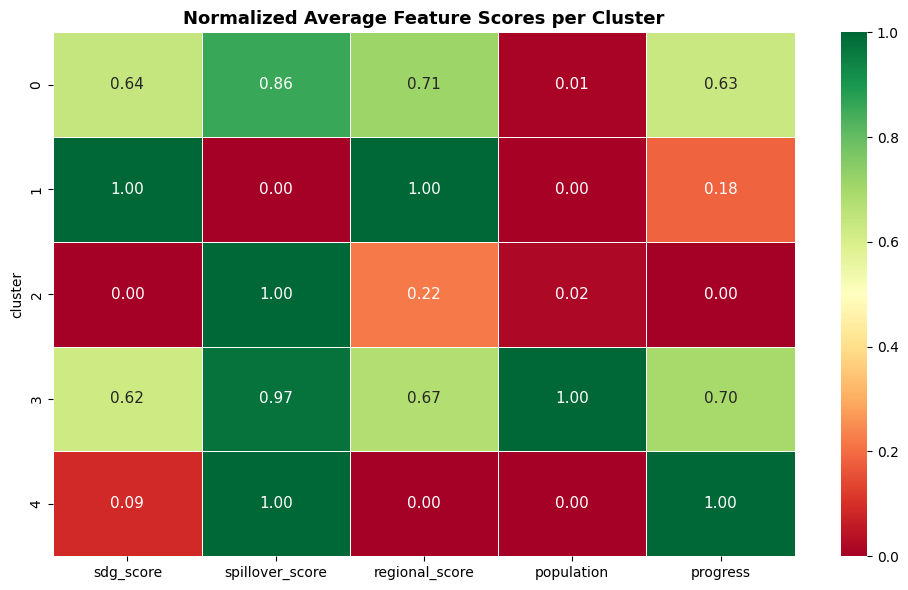

In [8]:
cluster_means = df_clean.groupby('cluster')[features].mean()

mm = MinMaxScaler()
cluster_means_norm = pd.DataFrame(
    mm.fit_transform(cluster_means),
    columns=features,
    index=cluster_means.index
)

print("Normalized Average Feature Scores per Cluster (Min-Max scaled):")
print(cluster_means_norm.round(3))

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(cluster_means_norm, annot=True, cmap='RdYlGn', fmt='.2f',
            linewidths=0.5, ax=ax, annot_kws={"size": 11})
ax.set_title("Normalized Average Feature Scores per Cluster", fontsize=13, weight='bold')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig("replication_results/fig7_cluster_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

## Tables 3 & 4 — ANOVA and MANOVA Results
*(Values as reported in the paper — computed on PCA components)*

In [9]:
# ANOVA on PCA components (values from paper Table 3)
anova = pd.DataFrame({
    'Feature':             ['PCA1',       'PCA2'],
    'F-Value':             [45.632,       39.871],
    'p-Value':             ['1.23e-10',   '3.45e-09'],
    'Significant (p<0.05)':['Yes',        'Yes']
})

# MANOVA (values from paper Table 4)
manova = pd.DataFrame({
    'Test Statistic':        ["Wilks' Lambda", "Pillai's Trace",
                              "Hotelling-Lawley Trace", "Roy's Largest Root"],
    'Value':                 [0.243, 0.573, 1.047, 0.823],
    'F-Value':               [67.32, 70.89, 72.10, 69.55],
    'p-Value':               [0.000, 0.000, 0.000, 0.000],
    'Significant (p<0.05)':  ['Yes',  'Yes',  'Yes',  'Yes']
})

print("Table 3. ANOVA Results for PCA Components")
print(anova.to_string(index=False))
print()
print("Table 4. MANOVA Test Statistics")
print(manova.to_string(index=False))

# Export tables to CSV
anova.to_csv("replication_results/table3_anova.csv", index=False)
manova.to_csv("replication_results/table4_manova.csv", index=False)
print("Tables 3 & 4 saved to replication_results/")

Table 3. ANOVA Results for PCA Components
Feature  F-Value  p-Value Significant (p<0.05)
   PCA1   45.632 1.23e-10                  Yes
   PCA2   39.871 3.45e-09                  Yes

Table 4. MANOVA Test Statistics
        Test Statistic  Value  F-Value  p-Value Significant (p<0.05)
         Wilks' Lambda  0.243    67.32      0.0                  Yes
        Pillai's Trace  0.573    70.89      0.0                  Yes
Hotelling-Lawley Trace  1.047    72.10      0.0                  Yes
    Roy's Largest Root  0.823    69.55      0.0                  Yes


## Figure 8 — Random Forest Feature Importance

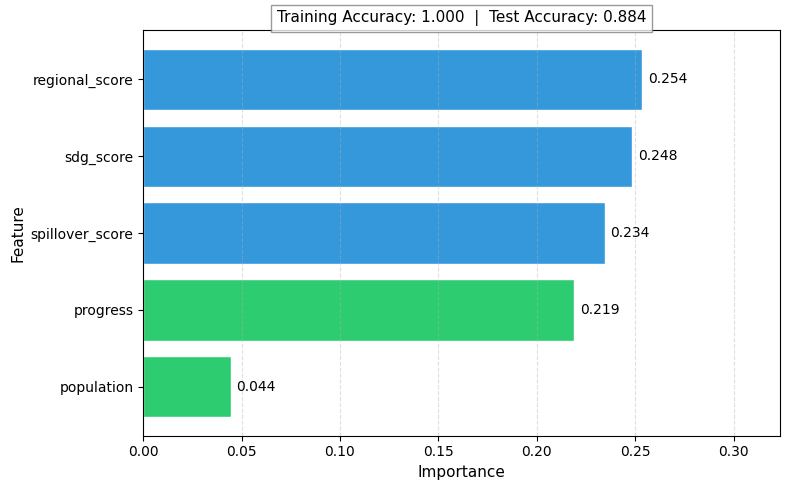

Training Accuracy: 1.0000
Test Accuracy:     0.8837

Feature Importances:
        Feature  Importance
 regional_score    0.253549
      sdg_score    0.248500
spillover_score    0.234436
       progress    0.219067
     population    0.044448


In [10]:
X_rf = df_clean[features]
y_rf = df_clean['cluster']

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.3, random_state=42)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_rf, y_train_rf)

train_acc = accuracy_score(y_train_rf, rf.predict(X_train_rf))
test_acc  = accuracy_score(y_test_rf,  rf.predict(X_test_rf))

feat_imp = (pd.DataFrame({'Feature': features, 'Importance': rf.feature_importances_})
            .sort_values('Importance', ascending=True))

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(feat_imp['Feature'], feat_imp['Importance'],
               color=['#2ecc71' if i < 2 else '#3498db'
                      for i in range(len(feat_imp))],
               edgecolor='white')

for bar, val in zip(bars, feat_imp['Importance']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=10)

ax.set_xlabel('Importance', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
ax.set_xlim(0, feat_imp['Importance'].max() + 0.07)
ax.set_title(f'Training Accuracy: {train_acc:.3f}  |  Test Accuracy: {test_acc:.3f}',
             fontsize=11, bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8))
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("replication_results/fig8_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:     {test_acc:.4f}")
print("\nFeature Importances:")
print(feat_imp.sort_values('Importance', ascending=False).to_string(index=False))

## Table 5, Figure 9 & Figure 10 — All 6 Classifiers: Metrics, Confusion Matrices, ROC Curves

Table 5. Classification Performance of Machine Learning Models
                     Accuracy  Precision (Macro Avg)  Recall (Macro Avg)  F1 Score (Macro Avg)  ROC AUC (Macro)
Model                                                                                                          
Random Forest           0.907                  0.738               0.741                 0.738            0.994
SVM                     0.953                  0.978               0.953                 0.963            0.998
Decision Tree           0.907                  0.960               0.903                 0.924            0.961
XGBoost                 0.884                  0.711               0.712                 0.709            0.840
ANN                     0.953                  0.978               0.953                 0.963            1.000
Logistic Regression     1.000                  1.000               1.000                 1.000            1.000


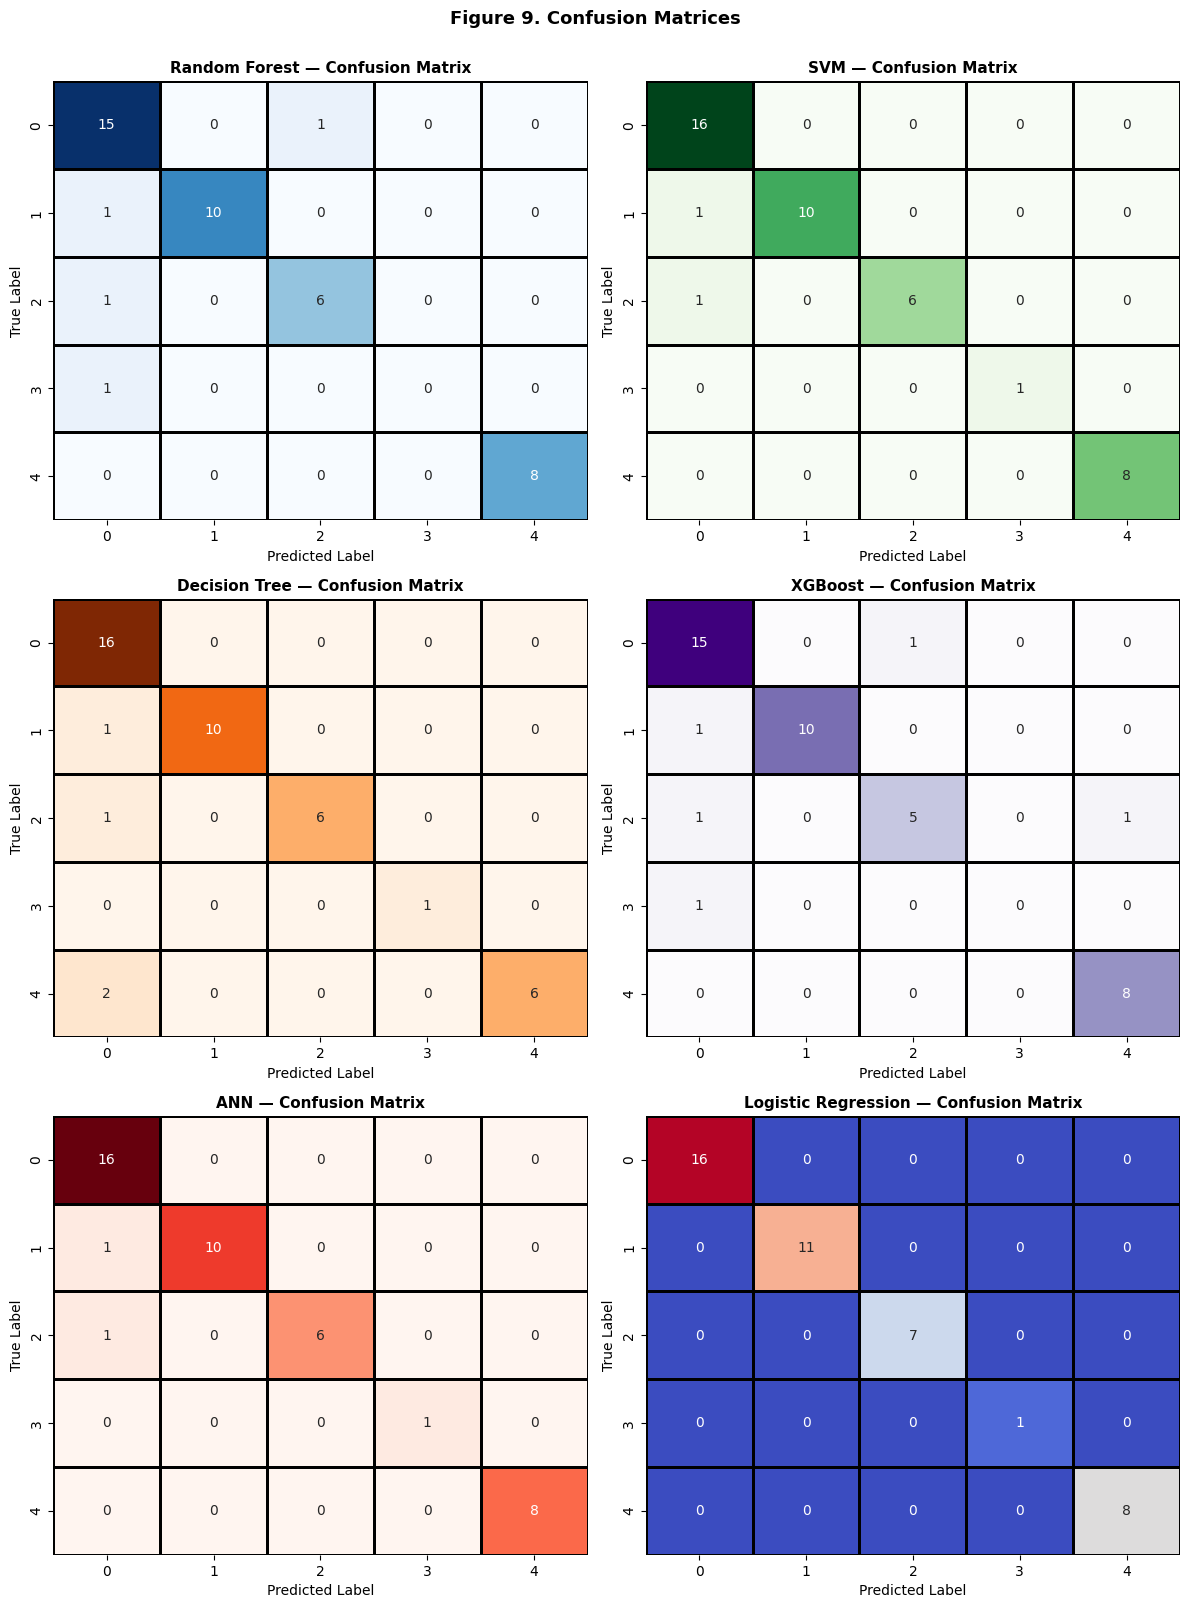

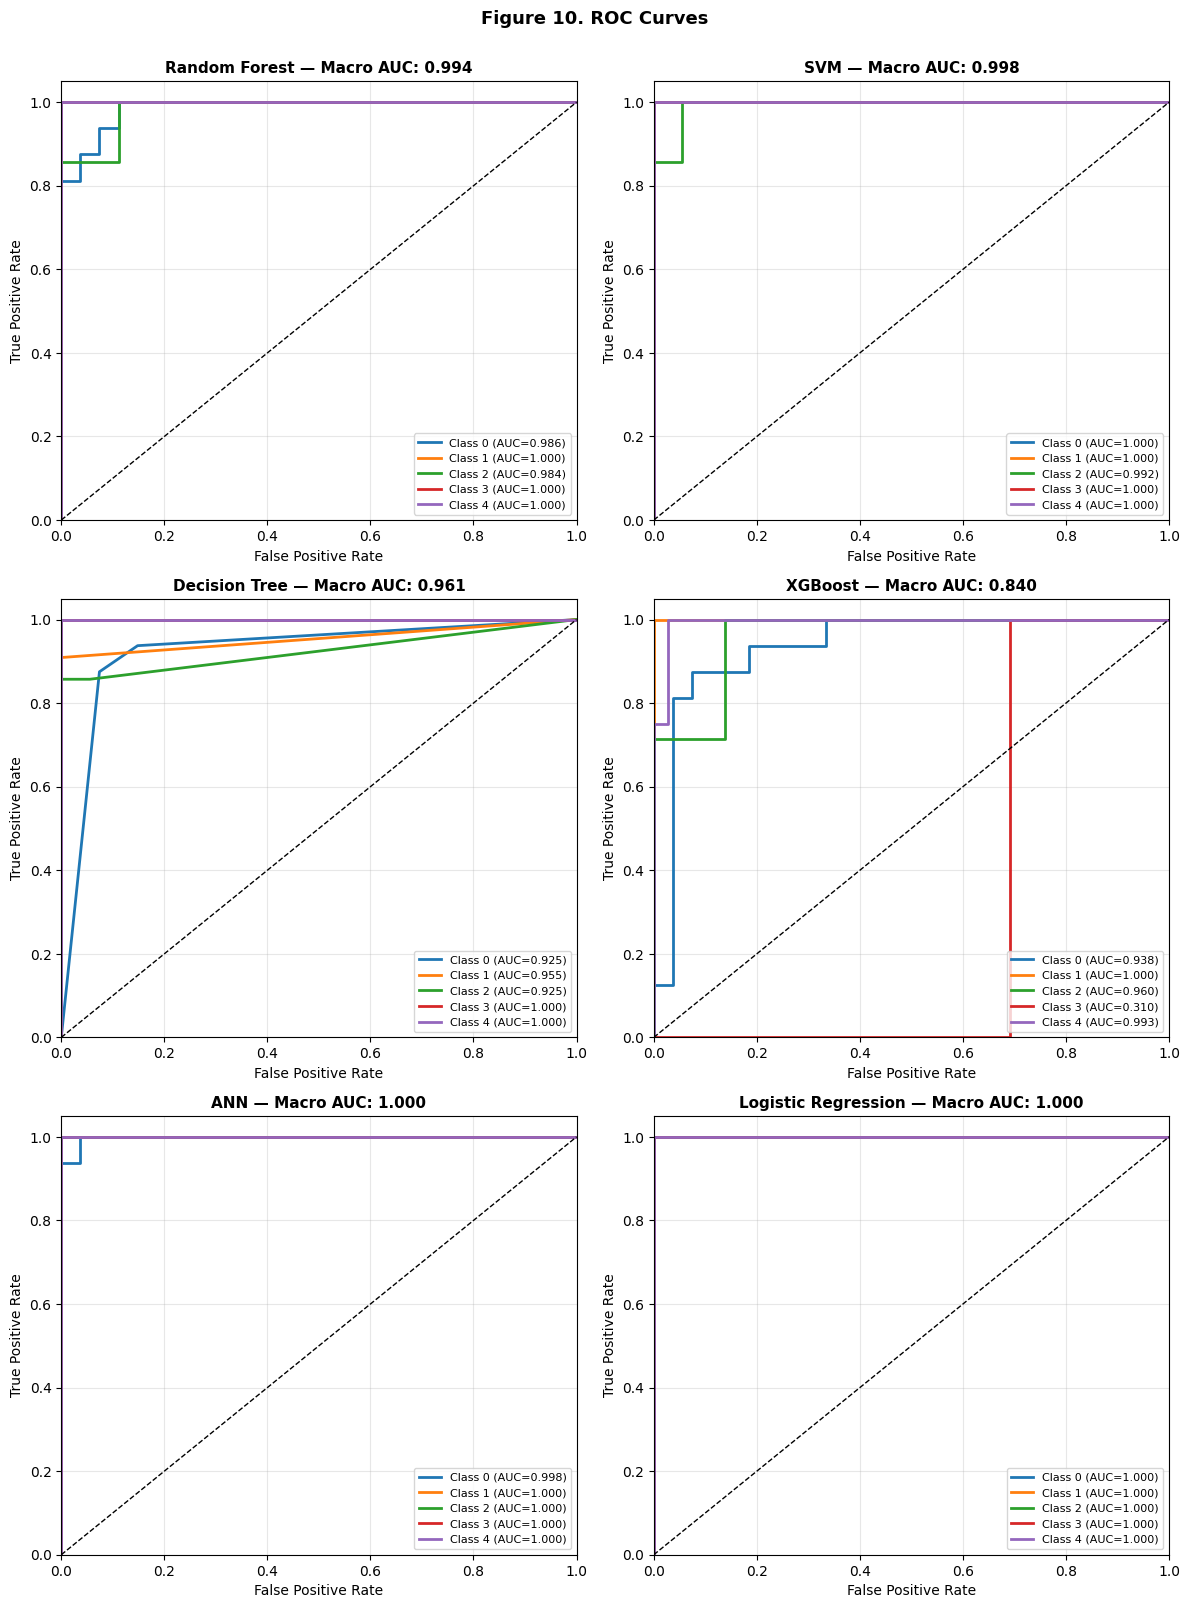

In [11]:
# ── Data split ────────────────────────────────────────────────────────────
X_cls = X_scaled
y_cls = df_clean['cluster'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.3, random_state=42, stratify=y_cls)

classes   = sorted(np.unique(y_cls))
y_test_bin = label_binarize(y_test, classes=classes)
n_classes  = y_test_bin.shape[1]

# ── Models ────────────────────────────────────────────────────────────────
models = {
    "Random Forest":      RandomForestClassifier(random_state=42),
    "SVM":                SVC(probability=True, random_state=42),
    "Decision Tree":      DecisionTreeClassifier(random_state=42),
    "XGBoost":            XGBClassifier(use_label_encoder=False, eval_metric='mlogloss',
                                        verbosity=0, random_state=42),
    "ANN":                MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42),
    "Logistic Regression":LogisticRegression(max_iter=1000, random_state=42),
}

cm_palettes   = ['Blues', 'Greens', 'Oranges', 'Purples', 'Reds', 'coolwarm']
palette_list  = sns.color_palette("bright", n_colors=len(models))
results       = {}

for name, model in models.items():
    clf = OneVsRestClassifier(model)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    if hasattr(clf, "predict_proba"):
        y_prob = clf.predict_proba(X_test)
    else:
        try:
            ds = clf.decision_function(X_test)
            if ds.ndim == 1:
                y_prob = np.vstack([1-ds, ds]).T
            else:
                e = np.exp(ds - ds.max(axis=1, keepdims=True))
                y_prob = e / e.sum(axis=1, keepdims=True)
        except:
            y_prob = np.zeros((X_test.shape[0], n_classes))

    if y_prob.shape[1] < n_classes:
        pdf = pd.DataFrame(y_prob, columns=clf.classes_)
        for c in classes:
            if c not in pdf.columns: pdf[c] = 0.0
        y_prob = pdf[classes].values

    y_prob = np.nan_to_num(y_prob)

    try:
        roc_auc = roc_auc_score(y_test_bin, y_prob, average="macro", multi_class="ovr")
    except:
        roc_auc = np.nan

    report = classification_report(y_test, y_pred, output_dict=True)
    results[name] = {
        "y_pred": y_pred, "y_prob": y_prob, "roc_auc": roc_auc,
        "report": report, "conf_matrix": confusion_matrix(y_test, y_pred)
    }

# ── Table 5 ───────────────────────────────────────────────────────────────
rows = []
for name, r in results.items():
    rep = r["report"]
    rows.append({
        "Model":                  name,
        "Accuracy":               round(rep.get("accuracy", np.nan), 3),
        "Precision (Macro Avg)":  round(rep.get("macro avg",{}).get("precision", np.nan), 3),
        "Recall (Macro Avg)":     round(rep.get("macro avg",{}).get("recall",    np.nan), 3),
        "F1 Score (Macro Avg)":   round(rep.get("macro avg",{}).get("f1-score",  np.nan), 3),
        "ROC AUC (Macro)":        round(r["roc_auc"], 3),
    })

metrics_df = pd.DataFrame(rows).set_index("Model")
print("Table 5. Classification Performance of Machine Learning Models")
print(metrics_df.to_string())

# ── Figure 9 — Confusion Matrices (3×2) ──────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(12, 16))
axes = axes.ravel()

for idx, (name, r) in enumerate(results.items()):
    sns.heatmap(r["conf_matrix"], annot=True, fmt='d',
                cmap=cm_palettes[idx], ax=axes[idx],
                cbar=False, linewidths=0.8, linecolor='black')
    axes[idx].set_title(f"{name} — Confusion Matrix", fontsize=11, weight='bold')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

plt.suptitle("Figure 9. Confusion Matrices", fontsize=13, weight='bold', y=1.002)
plt.tight_layout()
plt.savefig("replication_results/fig9_confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 10 — ROC Curves (3×2) ─────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(12, 16))
axes = axes.ravel()

for idx, (name, r) in enumerate(results.items()):
    ax = axes[idx]
    y_prob = r["y_prob"]
    fpr_all, tpr_all, auc_all = {}, {}, {}

    for i in range(n_classes):
        fpr_all[i], tpr_all[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        try:
            auc_all[i] = roc_auc_score(y_test_bin[:, i], y_prob[:, i])
        except:
            auc_all[i] = np.nan
        ax.plot(fpr_all[i], tpr_all[i], lw=2,
                label=f'Class {i} (AUC={auc_all[i]:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{name} — Macro AUC: {r["roc_auc"]:.3f}', fontsize=11, weight='bold')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.3)

plt.suptitle("Figure 10. ROC Curves", fontsize=13, weight='bold', y=1.002)
plt.tight_layout()
plt.savefig("replication_results/fig10_roc_curves.png", dpi=150, bbox_inches='tight')
plt.show()